# **Project 4 - Statistical Analysis using Python**

## Superstore Sales Dataset

### Objective
To apply statistical methods on the Superstore Sales dataset and interpret sales and profit patterns using descriptive statistics, correlation, and hypothesis-based analysis.



Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,5)

Load Dataset

In [3]:
df = pd.read_csv("Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Dataset Information

In [4]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (9994, 21)

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


Select Numerical Columns

In [5]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.head()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
0,1,42420,261.9600,2,0.00,41.9136
1,2,42420,731.9400,3,0.00,219.5820
2,3,90036,14.6200,2,0.00,6.8714
3,4,33311,957.5775,5,0.45,-383.0310
4,5,33311,22.3680,2,0.20,2.5164


Descriptive Statistics

In [6]:
numeric_df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Mean, Median, Mode

In [7]:
print("Mean Sales:", df["Sales"].mean())
print("Median Sales:", df["Sales"].median())
print("Mode Sales:", df["Sales"].mode()[0])

print("\nMean Profit:", df["Profit"].mean())
print("Median Profit:", df["Profit"].median())
print("Mode Profit:", df["Profit"].mode()[0])

Mean Sales: 229.85800083049833
Median Sales: 54.489999999999995
Mode Sales: 12.96

Mean Profit: 28.65689630778467
Median Profit: 8.6665
Mode Profit: 0.0


Variance and Standard Deviation


In [8]:
print("Sales Variance:", df["Sales"].var())
print("Sales Standard Deviation:", df["Sales"].std())

print("\nProfit Variance:", df["Profit"].var())
print("Profit Standard Deviation:", df["Profit"].std())

Sales Variance: 388434.45530807687
Sales Standard Deviation: 623.2451005086818

Profit Variance: 54877.79805537903
Profit Standard Deviation: 234.26010769095757


Minimum and Maximum Values

In [9]:
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())

print("\nMinimum Profit:", df["Profit"].min())
print("Maximum Profit:", df["Profit"].max())


Minimum Sales: 0.444
Maximum Sales: 22638.48

Minimum Profit: -6599.978
Maximum Profit: 8399.976


Correlation Analysis

In [10]:
correlation = numeric_df.corr()
correlation

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


Correlation Heatmap

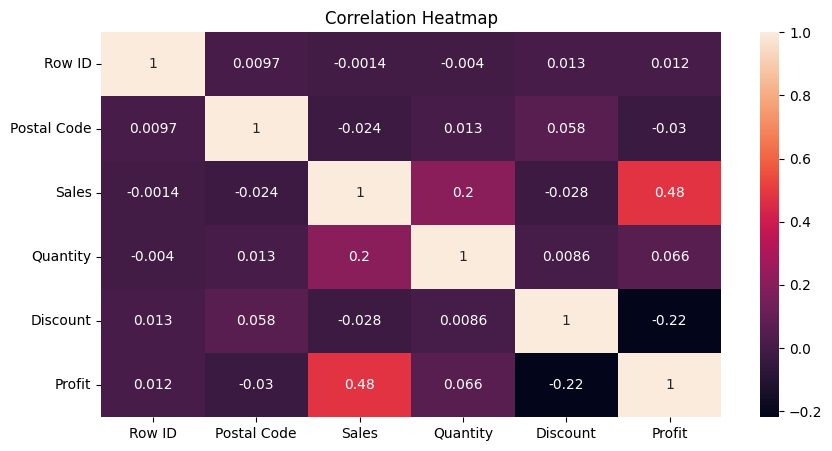

In [11]:
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

Hypothesis Section

# Hypothesis Testing

## Null Hypothesis (H0)
There is no relationship between Sales and Profit.

## Alternative Hypothesis (H1)
There is a relationship between Sales and Profit.

Sales-Profit Correlation

In [12]:
sales_profit_corr = df["Sales"].corr(df["Profit"])
print("Correlation between Sales and Profit:", sales_profit_corr)

Correlation between Sales and Profit: 0.4790643497377062


Scatter Plot for Hypothesis

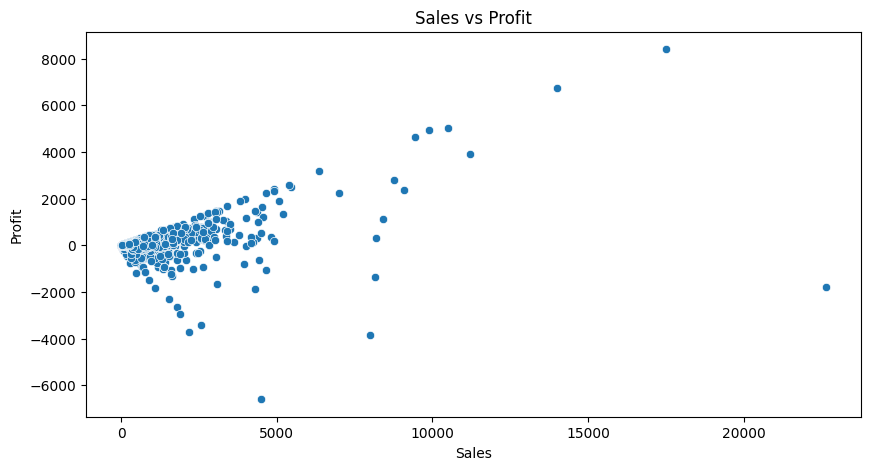

In [13]:
sns.scatterplot(x="Sales", y="Profit", data=df)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

## Interpretation

The correlation value between Sales and Profit helps understand whether both variables move together.

If the correlation value is positive, it means higher sales generally lead to higher profit.

If the value is close to 0, it means the relationship is weak.

From the scatter plot and correlation result, we can observe the relationship between sales and profit and make business-based conclusions.

Category-wise Statistical Analysis$0


In [14]:
category_stats = df.groupby("Category")[["Sales", "Profit"]].agg(["mean", "median", "std", "sum"])
category_stats

Sales                                        Profit  \
                       mean   median          std          sum       mean   
Category                                                                    
Furniture        349.834887  182.220   503.179145  741999.7953   8.699327   
Office Supplies  119.324101   27.418   382.182228  719047.0320  20.327050   
Technology       452.709276  166.160  1108.655848  836154.0330  78.752002   

                                                   
                  median         std          sum  
Category                                           
Furniture         7.7748  136.049246   18451.2728  
Office Supplies   6.8824  164.887280  122490.8008  
Technology       25.0182  428.816633  145454.9481

Region-wise Statistical Analysis

In [15]:
region_stats = df.groupby("Region")[["Sales", "Profit"]].agg(["mean", "median", "std", "sum"])
region_stats

Sales                                      Profit           \
               mean  median         std          sum       mean   median   
Region                                                                     
Central  215.772661  45.980  632.779010  501239.8908  17.092709   5.1840   
East     238.336110  54.900  620.712652  678781.2400  32.135808   8.1717   
South    241.803645  54.594  774.796273  391721.9050  28.857673   9.0720   
West     226.493233  60.840  524.876877  725457.8245  33.849032  11.1664   

                                  
                std          sum  
Region                            
Central  291.487465   39706.3625  
East     251.605084   91522.7800  
South    212.893088   46749.4303  
West     174.109081  108418.4489

Boxplot for Profit Variability

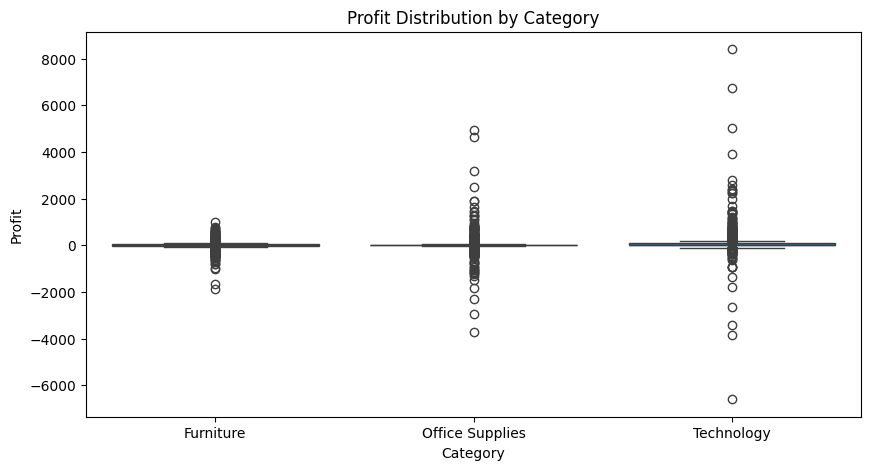

In [16]:
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Profit Distribution by Category")
plt.show()

# Key Findings

1. Descriptive statistics helped understand the central tendency and spread of sales and profit.

2. Sales and profit showed variation across different product categories.

3. Correlation analysis helped identify the relationship between numerical variables.

4. Boxplot analysis showed variability and possible outliers in profit values.

5. Statistical analysis supported better interpretation of business performance.

# Conclusion

Statistical analysis was performed on the Superstore Sales dataset using Python. Measures such as mean, median, mode, variance, standard deviation, correlation, and category-wise statistics were calculated. The results helped interpret sales and profit behavior and supported data-driven business decisions.